### Libraries 

In [1]:
import os
import glob
import nibabel as nb
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.mesh.mesh_io import read_surface

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# libraries
import numpy as np
from brainspace.plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from brainspace.mesh.mesh_creation import build_polydata
import copy
from brainstat.datasets import fetch_mask
import matplotlib.cm as cm
import scipy as sp
from matplotlib.colors import ListedColormap
import cmocean

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np; np.random.seed(2)
import random; random.seed(2)
import joypy
from sklearn.preprocessing import minmax_scale
from scipy.interpolate import interp1d

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

inf32_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
inf32_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-5k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-5k.R.sphere.surf.gii', itype='gii')

# load stuff
mask_32k = load_mask(join=True)
mask_surf32 = mask_32k != 0

# Labels and boolean mask
mask_surf = mask_5k != 0

# Inflated fsLR-5k surfaces
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsaverage5
fs5_lh = read_surface(micapipe+'/surfaces/fsaverage5/surf/lh.pial', itype='fs')
fs5_rh = read_surface(micapipe+'/surfaces/fsaverage5/surf/rh.pial', itype='fs')
fs5_mask = fetch_mask("fsaverage5")

### Load Intensity Profiles

In [69]:
# Load 10PNC-T1map
T1map_gm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_gmIP.npy')
T1map_swm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_swmIP.npy')
T1map_int_profile = np.vstack((T1map_gm_int, np.flip(T1map_swm_int, axis=0)))

# Load 10PNC-MTsat
MTSAT_gm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_gmIP.npy')
MTSAT_swm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_swmIP.npy')
MTSAT_int_profile = np.vstack((MTSAT_gm_int, np.flip(MTSAT_swm_int, axis=0)))

# Load BigBrain
BBgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/BB_GM_IPs_5k.npy')
BBswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/BB_SWM_IPs_5k.npy')
BB_int_profile = np.vstack((BBgm_int, BBswm_int))

# Load AHEAD-Bielschowsky
ABgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_gm_Bieloschowsky.npy')
ABfswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_Bieloschowsky_FS.npy')
AB_int_profile = np.vstack((ABgm_int, ABfswm_int))

# Load AHEAD-Parvalbumin
APgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_gm_Parvalbumin.npy')
APfswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_Parvalbumin_FS.npy')
AP_int_profile = np.vstack((APgm_int, APfswm_int))

### Functions

In [26]:
def plot_ridgeplot(matrix, matrix_df=None, Cmap='rocket', Range=(2.5, 4.5), Xlab="flair", save_path=None, title=None, single_color=None, single_color_alpha=0.5):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    # Ensure alpha is within the valid range
    if single_color_alpha < 0 or single_color_alpha > 1:
        raise ValueError("single_color_alpha must be between 0 and 1")

    # Prepare the data
    ai = matrix.flatten()
    subject = np.array([])
    id_x = np.array([])

    for i in range(matrix.shape[0]):
        label = np.array([str(i+1) for j in range(matrix.shape[1])])
        subject = np.concatenate((subject, label))
        id_label = np.array([matrix_df[i] for j in range(matrix.shape[1])])
        id_x = np.concatenate((id_x, id_label))

    d = {'feature': ai,
         'subject': subject,
         'id_x': id_x
        }
    df = pd.DataFrame(d)

    # Set up the plot
    f, axs = plt.subplots(nrows=matrix.shape[0], figsize=(3.468504*2.5, 2.220472*3.5), sharex=True, sharey=True)
    f.set_facecolor('none')

    x = np.linspace(Range[0], Range[1], 100)

    for i, ax in enumerate(axs, 1):
        sns.kdeplot(df[df["subject"]==str(i)]['feature'],
                    fill=True,
                    color="w",  # Set edge color to gray
                    alpha=0.25,
                    linewidth=1.5,
                    legend=False,  # Ensure legend is not included
                    ax=ax)
        
        ax.set_xlim(Range[0], Range[1])
        
        if single_color:
            color = single_color
        else:
            color = Cmap
        
        if single_color:
            # Apply single color with specified alpha
            im = ax.imshow(np.vstack([x, x]),
                           cmap=None,
                           aspect="auto",
                           extent=[*ax.get_xlim(), *ax.get_ylim()],
                           vmin=0, vmax=1)  # Use dummy values for vmin and vmax
            im.set_cmap(None)
            # Create RGBA color with specified alpha
            rgba_color = mpl.colors.to_rgba(single_color, alpha=single_color_alpha)
            im.set_array(np.array([[0.5]] * len(x)))  # Use a constant array for coloring
            im.set_cmap(mpl.colors.ListedColormap([rgba_color]))
        else:
            # Use the colormap
            im = ax.imshow(np.vstack([x, x]),
                           cmap=Cmap,
                           aspect="auto",
                           extent=[*ax.get_xlim(), *ax.get_ylim()]
                          )
        
        ax.collections
        path = ax.collections[0].get_paths()[0]
        patch = mpl.patches.PathPatch(path, transform=ax.transData)
        im.set_clip_path(patch)
           
        ax.spines[['left','right','bottom','top']].set_visible(False)
        
        if i != matrix.shape[0]:
            ax.tick_params(axis="x", length=0)
        else:
            ax.set_xlabel(Xlab)
            
        ax.set_yticks([])
        ax.set_ylabel("")
        
        ax.axhline(0, color="black")

        ax.set_facecolor("none")
        
        # Remove x-axis ticks and labels
        ax.set_xticks([])  # Remove x-axis ticks
        ax.set_xticklabels([])  # Remove x-axis tick labels

    # Removed the ax.text line to eliminate labels on the plot
    # ax.text(0.05, 0.01, matrix_df[i], transform=ax.transAxes, fontsize=10, color='black', ha='left', va='bottom')

    plt.subplots_adjust(hspace=-0.8)
    
    if title:
        plt.suptitle(title, y=0.99, fontsize=16)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()


## Vogt-Vogt (Baillarger type)

In [21]:
vogtBL_5k =  nb.load('/host/verges/tank/data/youngeun/Vogt-Vogt/MYATLAS_package_new/maps/Surface/HCP_conte69/conte69_32k/gii/parcellation/Baillarger_type_parcellation_fsLR5k_lh.shape.gii').darrays[0].data
vogtBR_5k =  nb.load('/host/verges/tank/data/youngeun/Vogt-Vogt/MYATLAS_package_new/maps/Surface/HCP_conte69/conte69_32k/gii/parcellation/Baillarger_type_parcellation_fsLR5k_rh.shape.gii').darrays[0].data
vogtB_5k = np.concatenate((vogtBL_5k, vogtBR_5k), axis=0)
vogtB_5k_round = np.round(vogtB_5k)

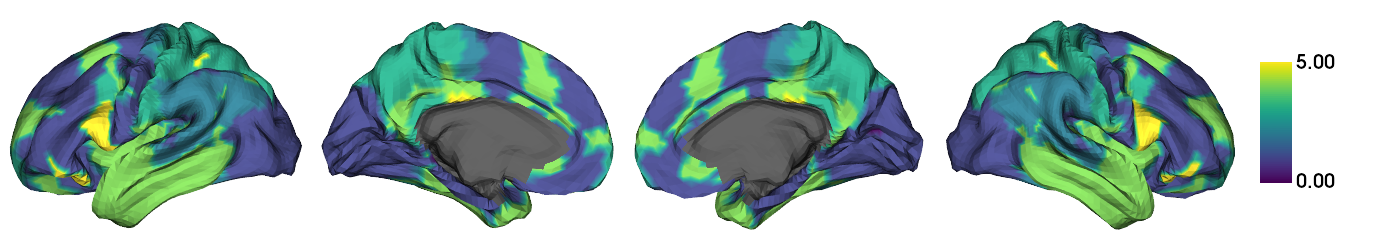

In [22]:
vogtB_5k_round[mask_5k == False] = np.nan

# plot labels on surface
plot_hemispheres(f5k_lh, f5k_rh, vogtB_5k_round, cmap='viridis', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

### 10PNC - T1map

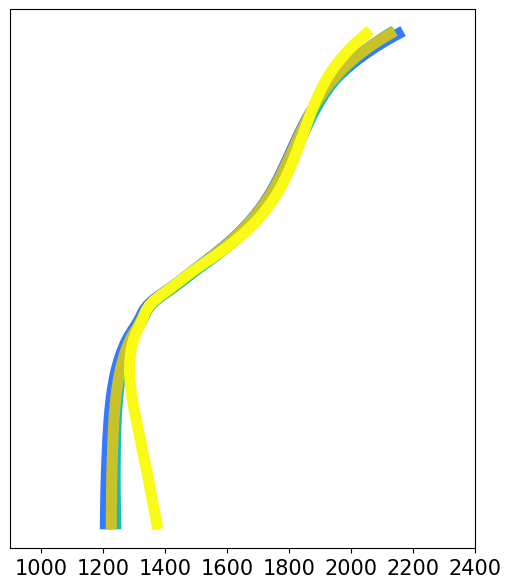

In [75]:
filtered_maps = {}
for value in range(6):
    filtered_map = np.where(vogtB_5k_round == value, np.flip(T1map_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 6):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (53/255, 121/255, 253/255), (16/255, 190/255, 186/255), (200/255, 193/255, 41/255), (249/255, 251/255, 21/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(900, 2400)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### 10PNC - MTsat

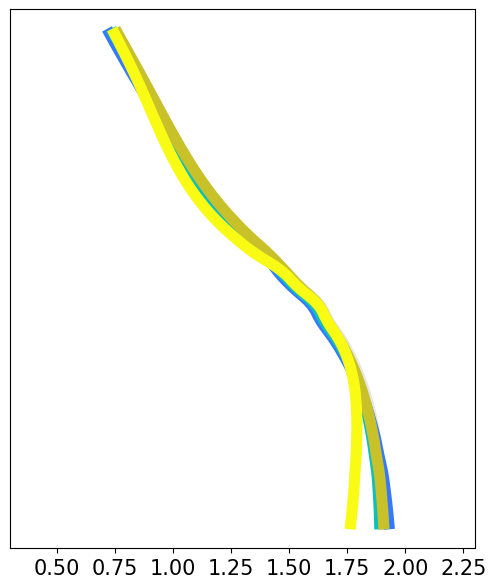

In [77]:
filtered_maps = {}
for value in range(6):
    filtered_map = np.where(vogtB_5k_round == value, np.flip(MTSAT_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 6):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (53/255, 121/255, 253/255), (16/255, 190/255, 186/255), (200/255, 193/255, 41/255), (249/255, 251/255, 21/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(0.3, 2.3)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### BigBrain

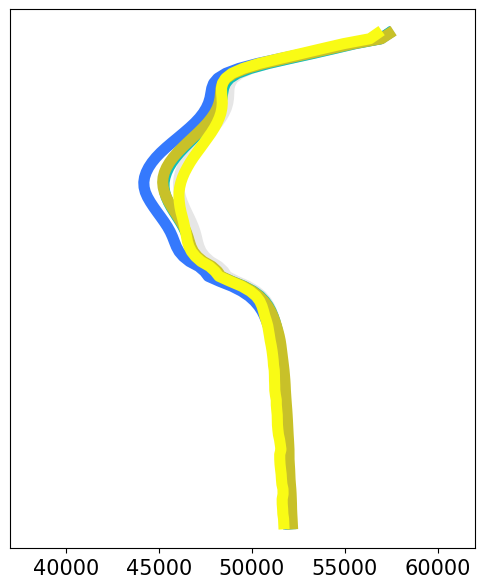

In [78]:
filtered_maps = {}
for value in range(6):
    filtered_map = np.where(vogtB_5k_round == value, np.flip(BB_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 6):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (53/255, 121/255, 253/255), (16/255, 190/255, 186/255), (200/255, 193/255, 41/255), (249/255, 251/255, 21/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(37000, 62000)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### AHEAD - Bielschowsky

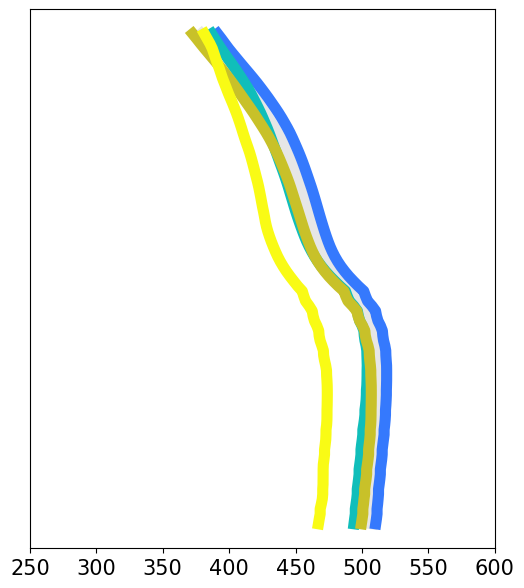

In [79]:
filtered_maps = {}
for value in range(6):
    filtered_map = np.where(vogtB_5k_round == value, np.flip(AB_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 6):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (53/255, 121/255, 253/255), (16/255, 190/255, 186/255), (200/255, 193/255, 41/255), (249/255, 251/255, 21/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(250, 600)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### AHEAD - Parvalbumin

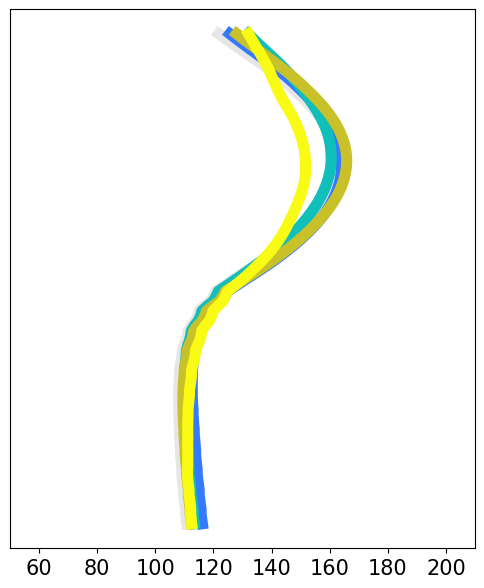

In [80]:
filtered_maps = {}
for value in range(6):
    filtered_map = np.where(vogtB_5k_round == value, np.flip(AP_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 6):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (53/255, 121/255, 253/255), (16/255, 190/255, 186/255), (200/255, 193/255, 41/255), (249/255, 251/255, 21/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(50, 210)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

## Vogt-Vogt (Intrusion type)

In [23]:
vogtIL_5k =  nb.load('/host/verges/tank/data/youngeun/Vogt-Vogt/MYATLAS_package_new/maps/Surface/HCP_conte69/conte69_32k/gii/parcellation/Intrusion_type_parcellation_fsLR5k_lh.shape.gii').darrays[0].data
vogtIR_5k =  nb.load('/host/verges/tank/data/youngeun/Vogt-Vogt/MYATLAS_package_new/maps/Surface/HCP_conte69/conte69_32k/gii/parcellation/Intrusion_type_parcellation_fsLR5k_rh.shape.gii').darrays[0].data
vogtI_5k = np.concatenate((vogtIL_5k, vogtIR_5k), axis=0)
vogtI_5k_round = np.round(vogtI_5k)

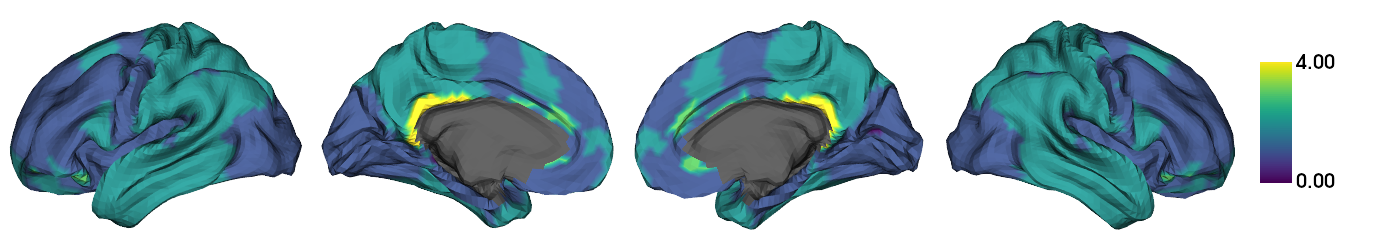

In [24]:
vogtI_5k_round[mask_5k == False] = np.nan

# plot labels on surface
plot_hemispheres(f5k_lh, f5k_rh, vogtI_5k_round, cmap='viridis', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

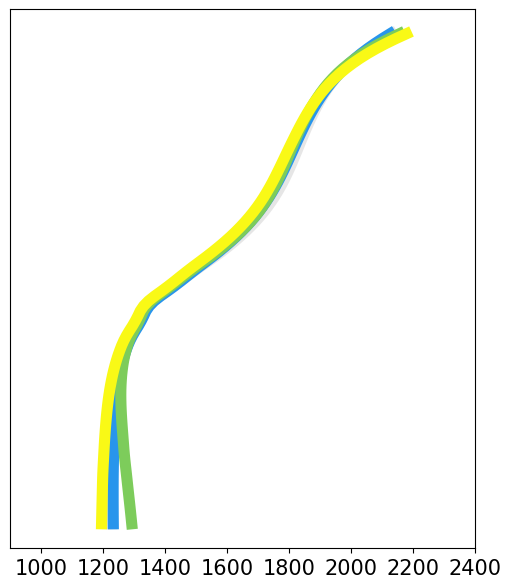

In [82]:
filtered_maps = {}
for value in range(5):
    filtered_map = np.where(vogtI_5k_round == value, np.flip(T1map_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 5):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (40/255, 149/255, 236/255), (125/255, 204/255, 91/255), (249/255, 249/255, 22/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(900, 2400)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

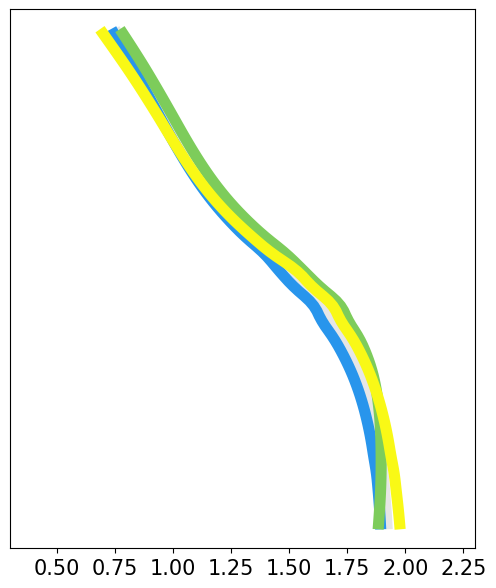

In [63]:
filtered_maps = {}
for value in range(5):
    filtered_map = np.where(vogtI_5k_round == value, np.flip(MTSAT_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 5):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (40/255, 149/255, 236/255), (125/255, 204/255, 91/255), (249/255, 249/255, 22/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(0.3, 2.3)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### BigBrain

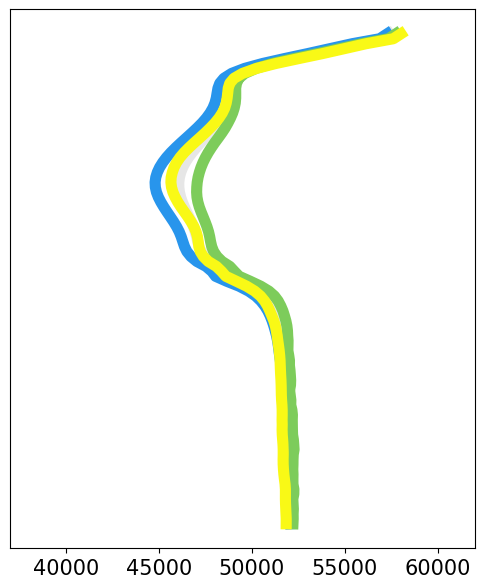

In [65]:
filtered_maps = {}
for value in range(5):
    filtered_map = np.where(vogtI_5k_round == value, np.flip(BB_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 5):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (40/255, 149/255, 236/255), (125/255, 204/255, 91/255), (249/255, 249/255, 22/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(37000, 62000)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### AHEAD - Bielschowsky

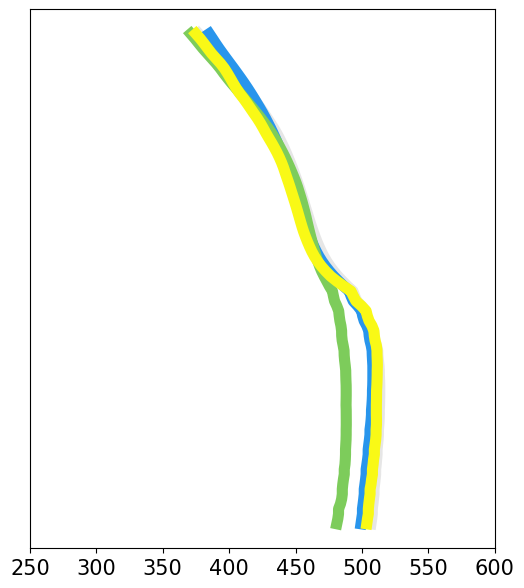

In [72]:
filtered_maps = {}
for value in range(5):
    filtered_map = np.where(vogtI_5k_round == value, np.flip(AB_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 5):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (40/255, 149/255, 236/255), (125/255, 204/255, 91/255), (249/255, 249/255, 22/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(250, 600)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### AEHAD - Parvalbumin

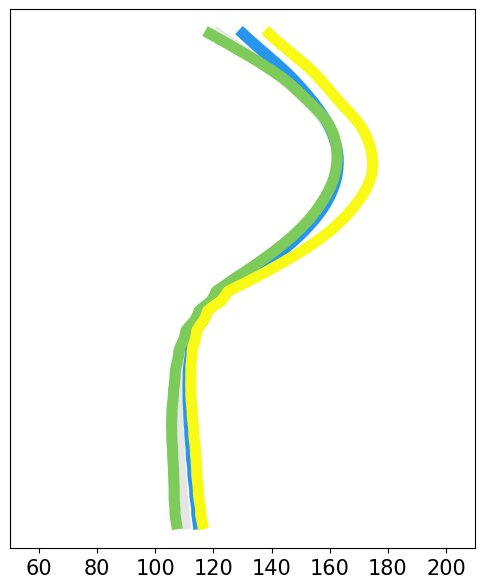

In [73]:
filtered_maps = {}
for value in range(5):
    filtered_map = np.where(vogtI_5k_round == value, np.flip(AP_int_profile), np.nan)
    filtered_maps[value] = filtered_map

mean_values_dict = {}
for key in range(1, 5):
    mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

# Plot
plt.figure(figsize=(6, 7))

# Smoothed profiles
smoothed_profiles = []
x_values = np.arange(mean_values_dict[1].shape[0])

for key in mean_values_dict:
    f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
    x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
    y_interp = f(x_interp)
    smoothed_profiles.append(y_interp)

# User-defined colors and line styles
colors_profiles = [(230/255, 230/255, 230/255), (40/255, 149/255, 236/255), (125/255, 204/255, 91/255), (249/255, 249/255, 22/255)]

# Plotting profiles
for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
    plt.plot(smoothed_profile, x_interp, color=color, linewidth=8)

plt.xlim(50, 210)
plt.yticks([])
plt.xticks(fontsize=15)
plt.show()

### Function

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_smoothed_profiles(ax, type, int_profile, x_lim=(0.0, 0.0), title=''):
    # Filtering based on type
    filtered_maps = {}
    if type is vogtB_5k_round:
        for value in range(6):
            filtered_map = np.where(vogtB_5k_round == value, np.flip(int_profile), np.nan)
            filtered_maps[value] = filtered_map
    elif type is vogtI_5k_round:
        for value in range(5):
            filtered_map = np.where(vogtI_5k_round == value, np.flip(int_profile), np.nan)
            filtered_maps[value] = filtered_map

    # Calculate mean values based on type
    mean_values_dict = {}
    if type is vogtB_5k_round:
        for key in range(1, 6):
            mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)
    elif type is vogtI_5k_round:
        for key in range(1, 5):
            mean_values_dict[key] = np.nanmean(filtered_maps[key], axis=1)

    # Smoothed profiles
    smoothed_profiles = []
    x_values = np.arange(mean_values_dict[1].shape[0])

    for key in mean_values_dict:
        f = interp1d(x_values, mean_values_dict[key], kind='quadratic')
        x_interp = np.linspace(0, len(mean_values_dict[key]) - 1, 100)
        y_interp = f(x_interp)
        smoothed_profiles.append(y_interp)

    # User-defined colors based on type
    if type is vogtB_5k_round:
        colors_profiles = [
            (230/255, 230/255, 230/255),  # Light grey
            (53/255, 121/255, 253/255),   # Blue
            (16/255, 190/255, 186/255),   # Teal
            (200/255, 193/255, 41/255),   # Gold
            (249/255, 251/255, 21/255)    # Yellow
        ]
    elif type is vogtI_5k_round:
        colors_profiles = [
            (230/255, 230/255, 230/255),  # Light grey
            (40/255, 149/255, 236/255),   # Blue
            (125/255, 204/255, 91/255),   # Green
            (249/255, 249/255, 22/255)    # Yellow
        ]

    # Plotting profiles on the given axis
    for smoothed_profile, color in zip(smoothed_profiles, colors_profiles):
        ax.plot(smoothed_profile, x_interp, color=color, linewidth=8)

    ax.set_xlim(x_lim)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=15)
    ax.set_title(title, fontsize=20)  # Add title to the subplot

    y_middle = (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2  
    ax.axhline(y=y_middle, color='red', linestyle='--', linewidth=2)  

## Vogt-Vogt (Baillarger type)

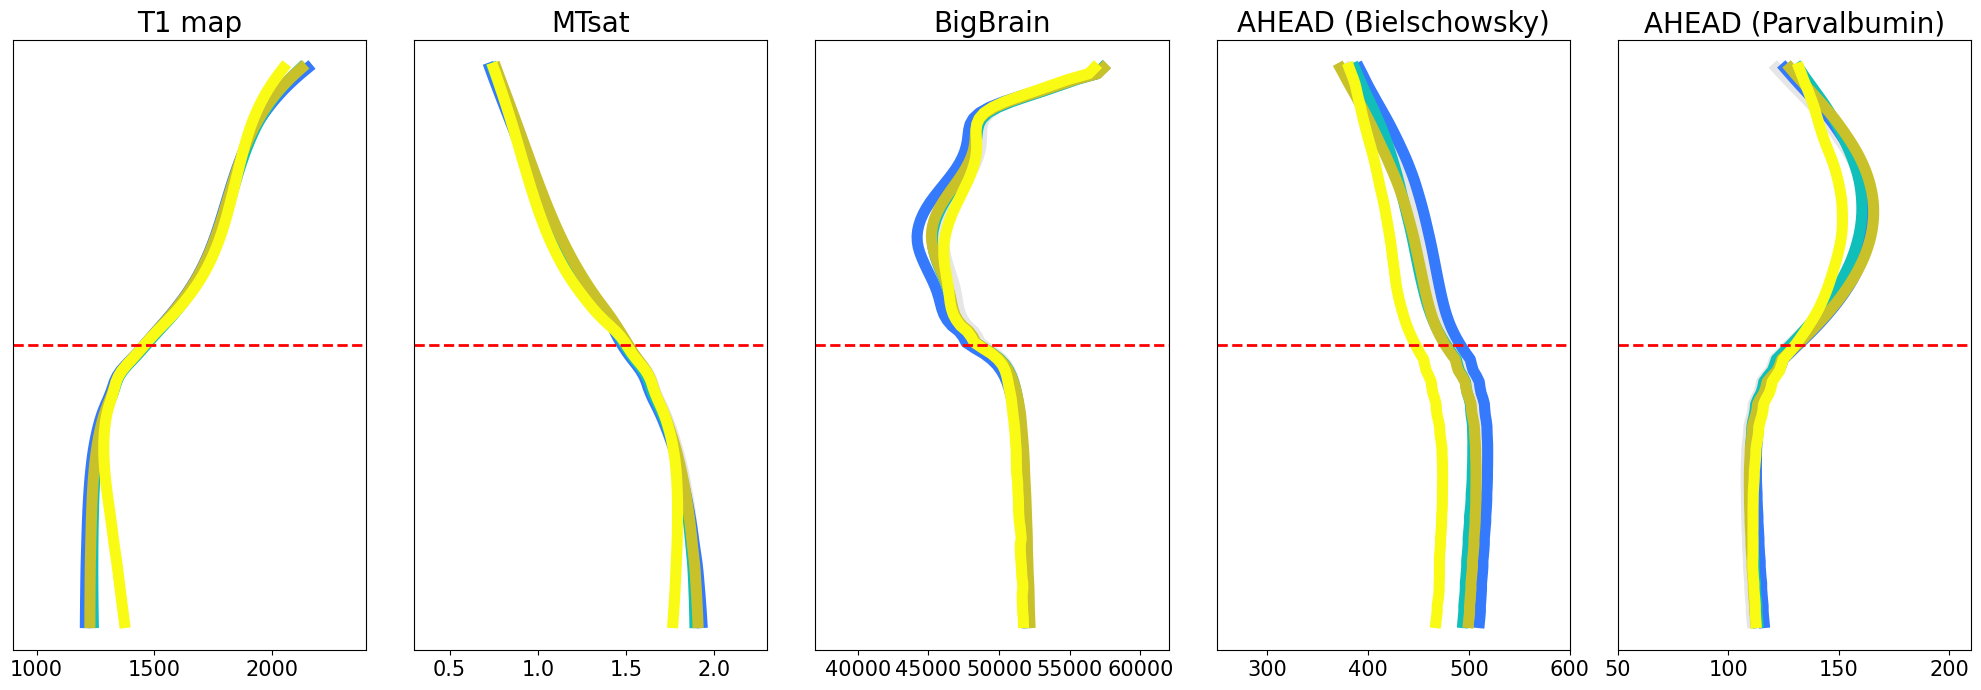

In [132]:
# Create a 1x5 subplot layout
fig, axs = plt.subplots(1, 5, figsize=(20, 7))
fig.patch.set_alpha(0.0)  # Set the background of the figure to be transparent

# Plot each profile on the respective subplot axis
plot_smoothed_profiles(axs[0], vogtB_5k_round, T1map_int_profile, x_lim=(900, 2400), title='T1 map')
plot_smoothed_profiles(axs[1], vogtB_5k_round, MTSAT_int_profile, x_lim=(0.3, 2.3), title='MTsat')
plot_smoothed_profiles(axs[2], vogtB_5k_round, BB_int_profile, x_lim=(37000, 62000), title='BigBrain')
plot_smoothed_profiles(axs[3], vogtB_5k_round, AB_int_profile, x_lim=(250, 600), title='AHEAD (Bielschowsky)')
plot_smoothed_profiles(axs[4], vogtB_5k_round, AP_int_profile, x_lim=(50, 210), title='AHEAD (Parvalbumin)')

plt.tight_layout()
plt.show()

## Vogt-Vogt (Intrusion type)

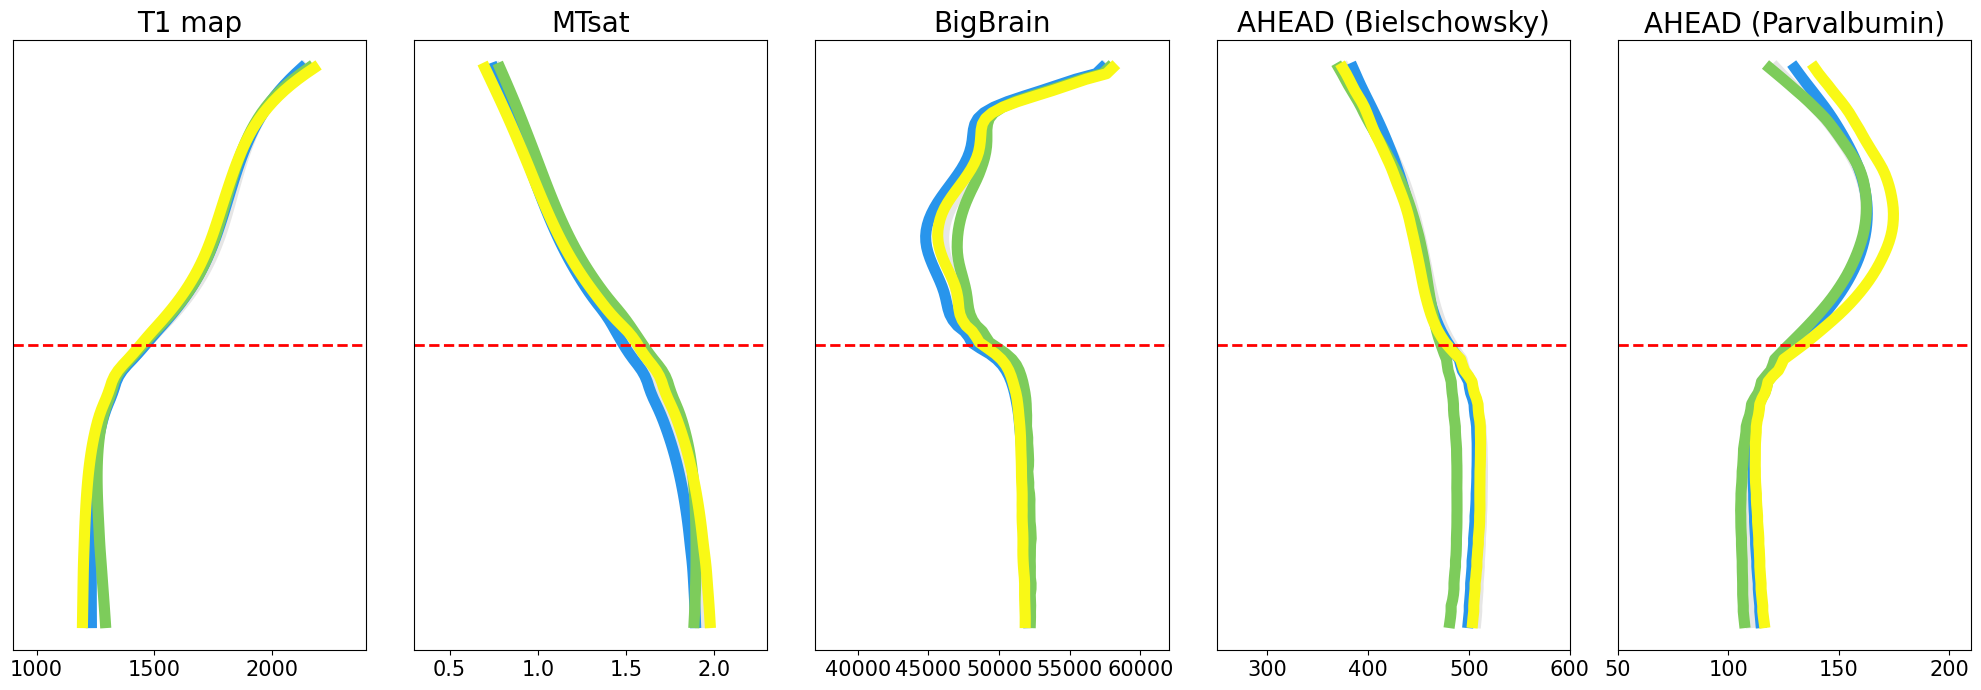

In [133]:
# Create a 1x5 subplot layout
fig, axs = plt.subplots(1, 5, figsize=(20, 7))
fig.patch.set_alpha(0.0)  # Set the background of the figure to be transparent

# Plot each profile on the respective subplot axis
plot_smoothed_profiles(axs[0], vogtI_5k_round, T1map_int_profile, x_lim=(900, 2400), title='T1 map')
plot_smoothed_profiles(axs[1], vogtI_5k_round, MTSAT_int_profile, x_lim=(0.3, 2.3), title='MTsat')
plot_smoothed_profiles(axs[2], vogtI_5k_round, BB_int_profile, x_lim=(37000, 62000), title='BigBrain')
plot_smoothed_profiles(axs[3], vogtI_5k_round, AB_int_profile, x_lim=(250, 600), title='AHEAD (Bielschowsky)')
plot_smoothed_profiles(axs[4], vogtI_5k_round, AP_int_profile, x_lim=(50, 210), title='AHEAD (Parvalbumin)')

plt.tight_layout()
plt.show()